# CS 178 Movie Review Project


##### Note: You might need to run pip install pyarrow and / or pip install fastparquet to access the dataset since its uses a .parquet extension


In [1]:
import pandas as pd

df = pd.read_parquet("../data/train.parquet")
df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [2]:
print(df.columns)
print()

print(df.info())

Index(['text', 'label'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None


In [3]:
#Positive Reviews 
df[df["label"] == 1].head(10)

,text,label
12500,Zentropa has much in common with The Third Man...,1
12501,Zentropa is the most original movie I've seen ...,1
12502,Lars Von Trier is never backward in trying out...,1
12503,*Contains spoilers due to me having to describ...,1
12504,That was the first thing that sprang to mind a...,1
12505,I had started to lose my faith in films of rec...,1
12506,Critics need to review what they class as a qu...,1
12507,It is not every film's job to stimulate you su...,1
12508,"The best way for me to describe Europa, which ...",1
12509,Released as Zentropa in North America to avoid...,1


In [4]:
#Negative Reviews
df[df["label"] == 0].head(10)

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


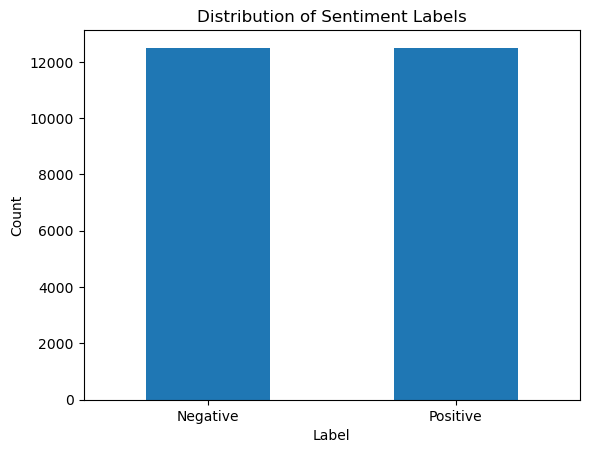

In [5]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0,1], ['Negative','Positive'], rotation=0)
plt.show()

The dataset is balanced with similar negative and positive review numbers. This is beneficial for classification since it prevents bias towards one type of label.

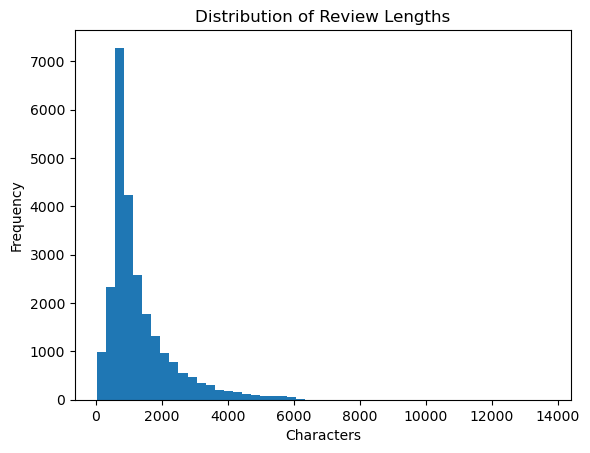

In [6]:
df["review_length"] = df["text"].apply(len)

plt.hist(df["review_length"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

Most reviews are between 0 - 6000 characters (approx.) with most reviews being shorter in length, while a smaller number of reviews are much longer. This is important since the longer reviews may contain more contextual information for sentiment prediction in our text prediction model.

In [7]:
df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64


The average review length is 1325 characters, with a median length of 979 characters. Review lengths vary significantly, ranging from 52 characters to 13,704 characters.

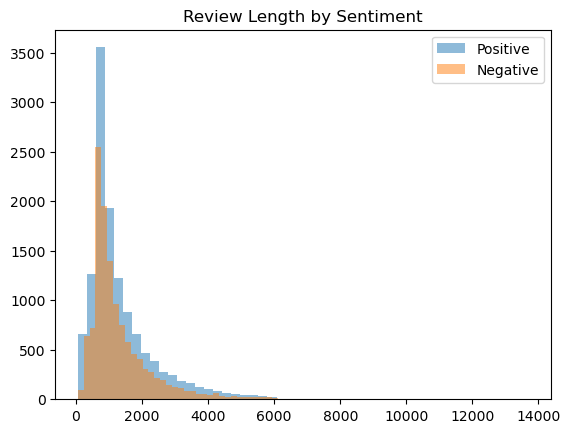

In [8]:
plt.hist(df[df.label==1].review_length, bins=50, alpha=0.5, label="Positive")
plt.hist(df[df.label==0].review_length, bins=50, alpha=0.5, label="Negative")
plt.legend()
plt.title("Review Length by Sentiment")
plt.show()

While longer reviews are more frequent for positive reviews, the distributions are similar.  Review length is not a strong indicator of sentiment, and the classification models will need to rely more on the content and wording of the reviews rather than their length.

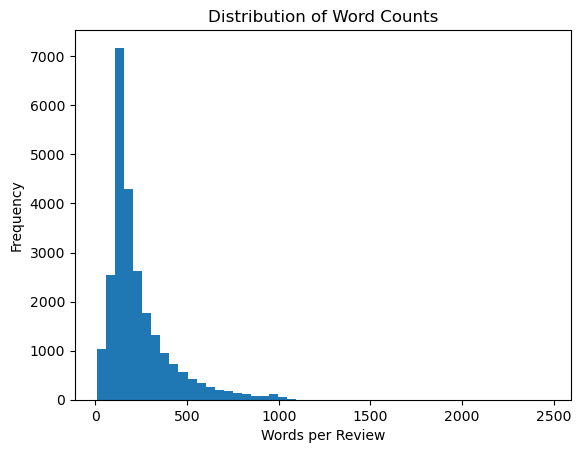

In [9]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Word Counts")
plt.xlabel("Words per Review")
plt.ylabel("Frequency")
plt.show()

Most reviews contain between 0 - 400 words, but some are significantly longer than the average.

##### 20 Most Frequently Occurring Words

In [10]:
from collections import Counter
import re

words = " ".join(df["text"]).lower()
words = re.findall(r'\b\w+\b', words)

Counter(words).most_common(20)

[('the', 336749),
 ('and', 164140),
 ('a', 163123),
 ('of', 145864),
 ('to', 135724),
 ('is', 107332),
 ('br', 101871),
 ('it', 96467),
 ('in', 93976),
 ('i', 87690),
 ('this', 76007),
 ('that', 73286),
 ('s', 63602),
 ('was', 48209),
 ('as', 46935),
 ('for', 44345),
 ('with', 44130),
 ('movie', 44047),
 ('but', 42623),
 ('film', 40159)]

Run pip install wordcloud in your project directory before running the code cell below

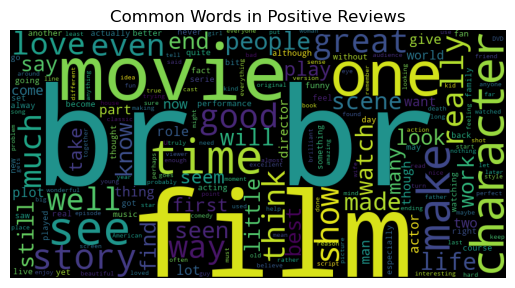

In [11]:
from wordcloud import WordCloud

text = " ".join(df[df.label==1]["text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Positive Reviews")
plt.show()

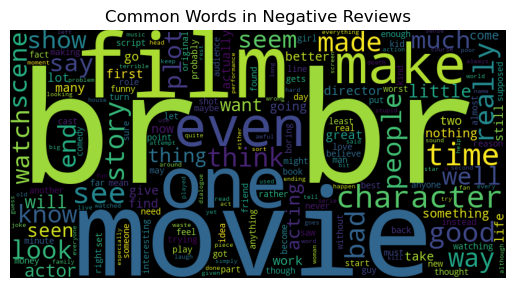

In [12]:
from wordcloud import WordCloud

text = " ".join(df[df.label==0]["text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Negative Reviews")
plt.show()

In [13]:
df.groupby("label")["word_count"].mean()

label
0    230.86784
1    236.70656
Name: word_count, dtype: float64

Average Length By Sentiment

Positive reviews are slightly longer than the negative reviews on average, showing that people tend to include more detailed descriptions when talking about movies they like.

##### Positive and Negative Review Example

In [14]:
print("Example of a positive review")
print(df[df.label==1]["text"].iloc[0])
print()

print("Example of a negative review")
print(df[df.label==0]["text"].iloc[0])
print()

Example of a positive review
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.

Example of a negative review
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to 